In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch

# Load Data
df = pd.read_csv('adult_dataset.csv')
df = df.drop('income', axis=1)
#df_clustering=df.copy()
df


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39.0,State-gov,77516,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,NaN
1,50.0,Self-emp-not-inc,83311,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States
2,38.0,Private,215646,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States
3,53.0,Private,234721,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States
4,28.0,Private,338409,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19063,41.0,Self-emp-not-inc,203451,Some-college,10.0,Divorced,Prof-specialty,Not-in-family,White,Female,0.0,0.0,15.0,United-States
19064,31.0,Private,109917,7th-8th,4.0,Separated,NaN,Not-in-family,White,Female,0.0,0.0,40.0,United-States
19065,31.0,Private,114937,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Husband,White,Male,0.0,0.0,35.0,United-States
19066,53.0,Local-gov,231196,HS-grad,9.0,Married-civ-spouse,Adm-clerical,Husband,White,Male,0.0,0.0,40.0,United-States


In [2]:
df.duplicated().sum()


np.int64(5)

In [3]:
# 1. Preprocessing
df.replace('?', np.nan, inplace=True)
df.isna().sum()

,0
age,945
workclass,1966
fnlwgt,0
education,0
education-num,1
marital-status,1
occupation,1983
relationship,1
race,1
sex,1


In [14]:
numeric_cols

Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')

In [4]:
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    df[col].fillna(df[col].median(), inplace=True)
for col in df.select_dtypes(include=['object']).columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

df.isnull().sum()

/tmp/ipython-input-396041143.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipython-input-396041143.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [5]:
df=df.drop_duplicates()

In [6]:
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include=['object']).columns:
    df[col].fillna(df[col].mode()[0], inplace=True)


/tmp/ipython-input-4012665293.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipython-input-4012665293.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipython-input-4012665293.py:5: FutureWarning: A value is trying to be set on a cop

In [7]:
from sklearn.preprocessing import StandardScaler

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[numeric_cols])


In [8]:
import numpy as np
np.isnan(X_scaled).sum()


np.int64(0)

In [9]:
# DBSCAN for anomaly detection
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
db = DBSCAN(eps=10, min_samples=5)
db.fit(X_scaled)

# Labels: -1 = anomaly, 0,1,... = cluster IDs
df['DBSCAN_Label'] = db.labels_
df


/tmp/ipython-input-736051404.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['DBSCAN_Label'] = db.labels_


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,DBSCAN_Label
0,39.0,State-gov,77516,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,0
1,50.0,Self-emp-not-inc,83311,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States,0
2,38.0,Private,215646,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States,0
3,53.0,Private,234721,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States,0
4,28.0,Private,338409,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19063,41.0,Self-emp-not-inc,203451,Some-college,10.0,Divorced,Prof-specialty,Not-in-family,White,Female,0.0,0.0,15.0,United-States,0
19064,31.0,Private,109917,7th-8th,4.0,Separated,Prof-specialty,Not-in-family,White,Female,0.0,0.0,40.0,United-States,0
19065,31.0,Private,114937,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Husband,White,Male,0.0,0.0,35.0,United-States,0
19066,53.0,Local-gov,231196,HS-grad,9.0,Married-civ-spouse,Adm-clerical,Husband,White,Male,0.0,0.0,40.0,United-States,0


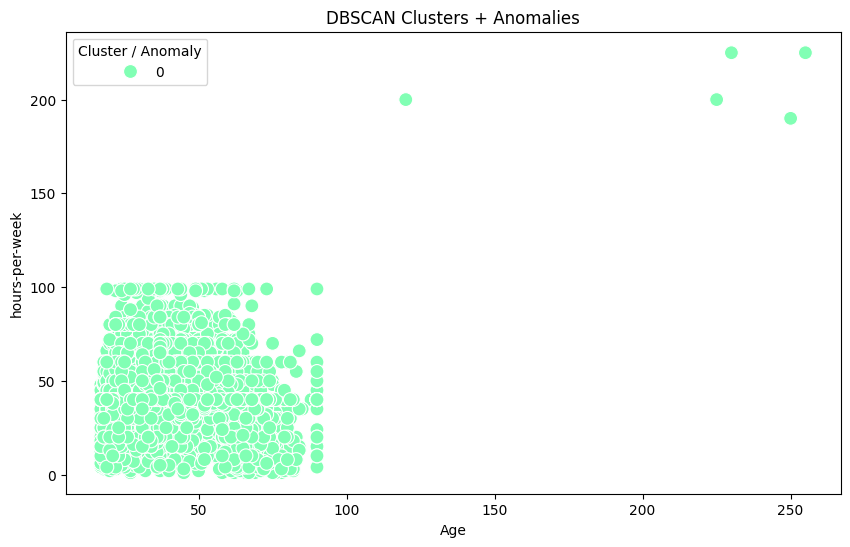

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Scatter plot with cluster labels as hue
sns.scatterplot(
    data=df,
    x='age',
    y='hours-per-week',
    hue='DBSCAN_Label',        # color points by cluster
    palette='rainbow',           # nice color palette
    # anomalies get different marker
    s=100                      # size of points
)

plt.title('DBSCAN Clusters + Anomalies')
plt.xlabel('Age')
plt.ylabel('hours-per-week')
plt.legend(title='Cluster / Anomaly')
plt.show()


In [15]:
from sklearn.cluster import KMeans

# Step 1: Remove anomalies
good_data = df[df['DBSCAN_Label'] != -1]

# Step 2: Features for K-Means
X_good = good_data[['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week']].values

# Step 3: Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
good_data['KMeans_Cluster'] = kmeans.fit_predict(X_good)

good_data


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,DBSCAN_Label,KMeans_Cluster
0,39.0,State-gov,77516,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,0,0
1,50.0,Self-emp-not-inc,83311,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States,0,0
2,38.0,Private,215646,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States,0,1
3,53.0,Private,234721,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States,0,1
4,28.0,Private,338409,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19063,41.0,Self-emp-not-inc,203451,Some-college,10.0,Divorced,Prof-specialty,Not-in-family,White,Female,0.0,0.0,15.0,United-States,0,1
19064,31.0,Private,109917,7th-8th,4.0,Separated,Prof-specialty,Not-in-family,White,Female,0.0,0.0,40.0,United-States,0,0
19065,31.0,Private,114937,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Husband,White,Male,0.0,0.0,35.0,United-States,0,0
19066,53.0,Local-gov,231196,HS-grad,9.0,Married-civ-spouse,Adm-clerical,Husband,White,Male,0.0,0.0,40.0,United-States,0,1


In [16]:
cluster_summary = good_data.groupby("KMeans_Cluster").agg({'age':["mean"],
                                                           'fnlwgt':["mean"],
                                                           'education-num':["mean"],
                                                           'capital-gain':["mean"],
                                                           'capital-loss':["mean"],


})

cluster_summary


,age,fnlwgt,education-num,capital-gain,capital-loss
,mean,mean,mean,mean,mean
KMeans_Cluster,,,,,
0,39.483269,94352.021786,10.177132,967.530258,94.993165
1,38.385768,206077.970782,10.081833,1108.468248,84.544798
2,36.702967,378881.255065,9.882055,1148.343343,80.367583
